In [10]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from preprocessing.preprocessing_utils import preprocess_for_tree

In [3]:
train = pd.read_csv("../data/claims_train.csv")

In [4]:
train["ClaimRate"] = train["ClaimNb"] / train["Exposure"]

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542410 entries, 0 to 542409
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       542410 non-null  float64
 1   ClaimNb     542410 non-null  int64  
 2   Exposure    542410 non-null  float64
 3   Area        542410 non-null  object 
 4   VehPower    542410 non-null  int64  
 5   VehAge      542410 non-null  int64  
 6   DrivAge     542410 non-null  int64  
 7   BonusMalus  542410 non-null  int64  
 8   VehBrand    542410 non-null  object 
 9   VehGas      542410 non-null  object 
 10  Density     542410 non-null  int64  
 11  Region      542410 non-null  object 
 12  ClaimRate   542410 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 53.8+ MB


In [21]:
train.isna().sum()   # count missing values

IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
ClaimRate     0
dtype: int64

In [6]:
train.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,ClaimRate
count,5.424100e+05,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000,542410.000000
mean,2.623260e+06,0.053122,0.528840,6.453281,7.045768,45.503164,59.761546,1796.176180,0.261192
std,1.641809e+06,0.238785,0.364463,2.050506,5.660827,14.135435,15.639321,3965.475251,4.428120
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000,0.000000
25%,1.158401e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000,0.000000
50%,2.272434e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000,0.000000
75%,4.046606e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1662.000000,0.000000
max,6.114330e+06,11.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000,732.000000


In [20]:
train.describe(include='all')

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimRate
count,5.414160e+05,541416.00000,541416.000000,541416,541416.000000,541416.000000,541416.000000,541416.000000,541416,541416,541416.000000,541416,541416.000000
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22,NaN
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,Regular,NaN,R24,NaN
freq,NaN,NaN,NaN,152993,NaN,NaN,NaN,NaN,132779,276223,NaN,128445,NaN
mean,2.625462e+06,0.05314,0.527763,NaN,6.452726,7.043473,45.502983,59.766195,NaN,NaN,1795.926642,NaN,0.261601
std,1.642401e+06,0.23883,0.363861,NaN,2.050219,5.659153,14.137967,15.645146,NaN,NaN,3966.464847,NaN,4.432165
min,1.000000e+00,0.00000,0.002732,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,1.000000,NaN,0.000000
25%,1.157748e+06,0.00000,0.170000,NaN,5.000000,2.000000,34.000000,50.000000,NaN,NaN,91.000000,NaN,0.000000
50%,2.273010e+06,0.00000,0.490000,NaN,6.000000,6.000000,44.000000,50.000000,NaN,NaN,393.000000,NaN,0.000000
75%,4.047446e+06,0.00000,0.990000,NaN,7.000000,11.000000,55.000000,64.000000,NaN,NaN,1662.000000,NaN,0.000000


In [7]:
invalid_rows = train[(train["Exposure"] > 1) | (train["Exposure"] == 0)]
print(f"Removed rows where exposure over 1 or equal to 0: {len(invalid_rows)}")
train = train[(train["Exposure"] <= 1) & (train["Exposure"] > 0)]

Removed rows where exposure over 1 or equal to 0: 994


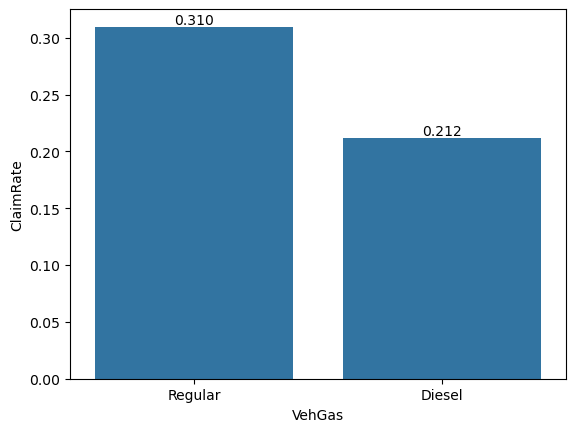

In [26]:
ax = sns.barplot(x="VehGas", y="ClaimRate", data=train, errorbar=None)
ax.bar_label(ax.containers[0], fmt="%.3f")  # shows mean ClaimRate on top
plt.show()

Text(0.5, 1.0, 'Distribution of Exposure (Time at Risk)')

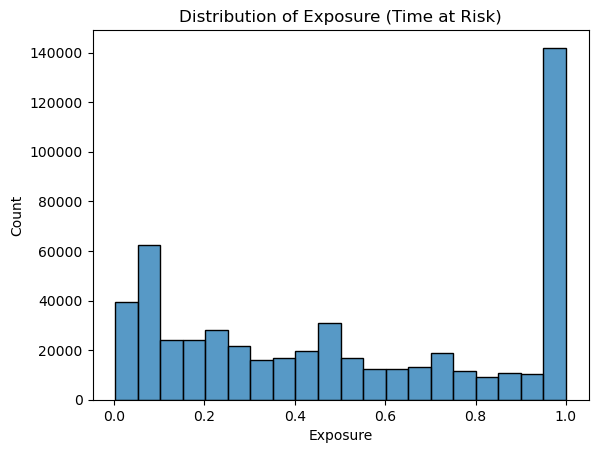

In [22]:
sns.histplot(train["Exposure"], bins=20)
plt.title("Distribution of Exposure (Time at Risk)")

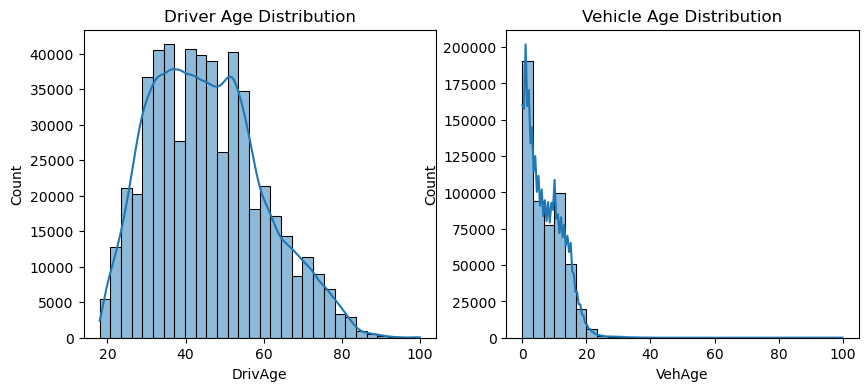

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(train["DrivAge"], bins=30, ax=axes[0], kde=True)
axes[0].set_title("Driver Age Distribution")

sns.histplot(train["VehAge"], bins=30, ax=axes[1], kde=True)
axes[1].set_title("Vehicle Age Distribution")
plt.show()

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_72423/1528120941.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Area", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)


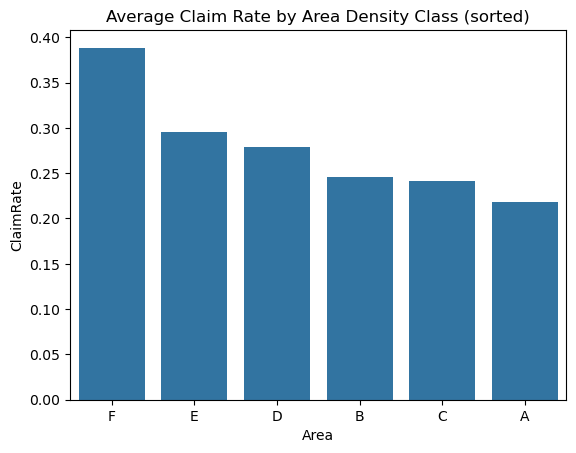

In [28]:
order = train.groupby("Area")["ClaimRate"].mean().sort_values(ascending=False).index

sns.barplot(x="Area", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)
plt.title("Average Claim Rate by Area Density Class (sorted)")
plt.show()

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_72423/72683943.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Region", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)


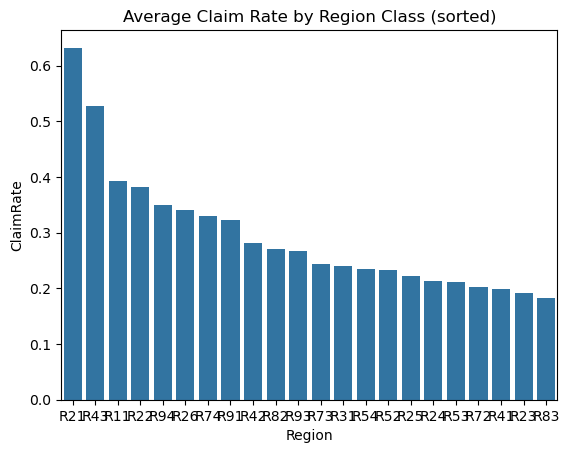

In [30]:
order = train.groupby("Region")["ClaimRate"].mean().sort_values(ascending=False).index

sns.barplot(x="Region", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)
plt.title("Average Claim Rate by Region Class (sorted)")
plt.show()

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_72423/3553067172.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Region", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)


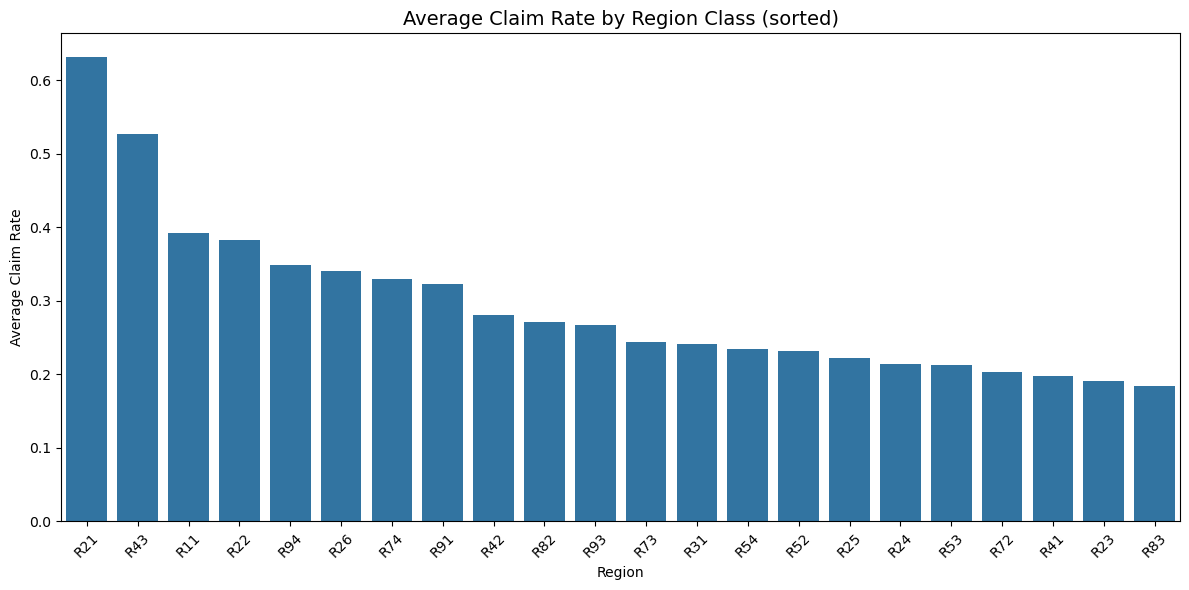

In [33]:
order = train.groupby("Region")["ClaimRate"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))  # 👈 make it wider (try 14 or 16 if needed)
sns.barplot(x="Region", y="ClaimRate", data=train, estimator="mean", ci=None, order=order)
plt.title("Average Claim Rate by Region Class (sorted)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Average Claim Rate")
plt.xticks(rotation=45)  # 👈 rotate labels if many regions
plt.tight_layout()
plt.show()

/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_72423/1673443427.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = train.groupby("DrivAgeBin")["ClaimRate"].mean().sort_values(ascending=False).index
/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_72423/1673443427.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="DrivAgeBin", y="ClaimRate", data=train, ci=None, order=order)


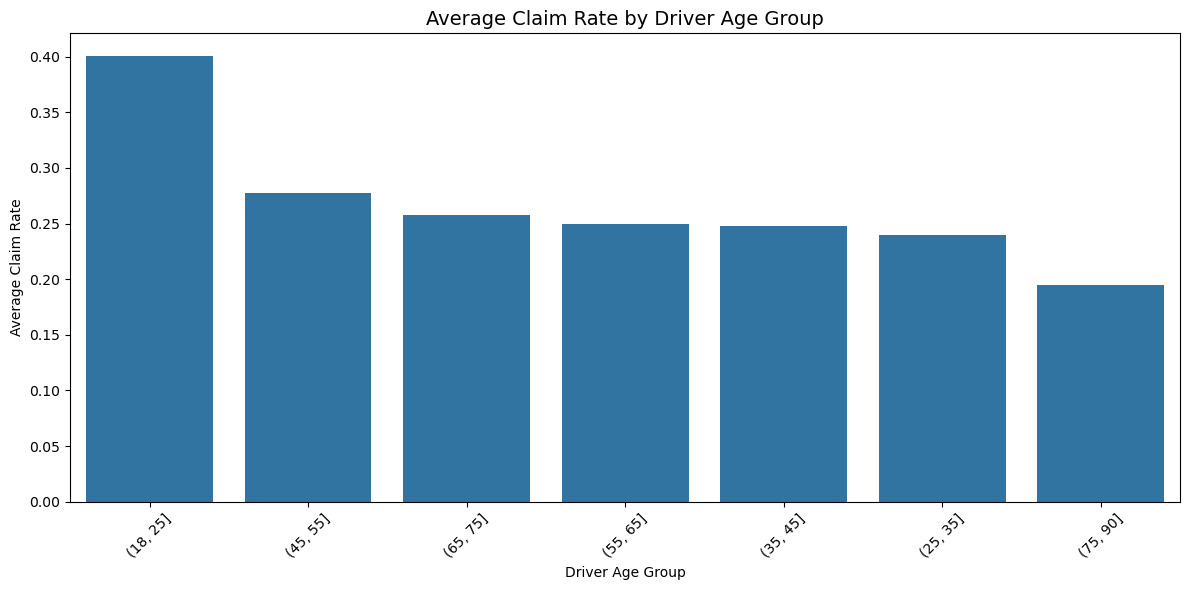

In [34]:
# Create age bins
train["DrivAgeBin"] = pd.cut(train["DrivAge"], bins=[18, 25, 35, 45, 55, 65, 75, 90])

order = train.groupby("DrivAgeBin")["ClaimRate"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(x="DrivAgeBin", y="ClaimRate", data=train, ci=None, order=order)
plt.title("Average Claim Rate by Driver Age Group", fontsize=14)
plt.xlabel("Driver Age Group")
plt.ylabel("Average Claim Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()